In [ ]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import CSVLogger
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

tf.keras.backend.clear_session()

# Set Random Seed
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

print("Libraries loaded. Random Seed 42 has been locked.")

Libraries loaded. Random Seed 42 has been locked.


In [ ]:
print("Downloading dataset")
!pip install gdown -q
!gdown 1b67VYi8SuLv8ru8oFNC9ZqZBLynZ4F3V -O dataset_split_224.zip

print("\nExtracting dataset")
!rm -rf dataset_siap_pakai
!unzip -q dataset_split_224.zip -d dataset_siap_pakai
print("Dataset extracted successfully!")

Downloading...
From: https://drive.google.com/uc?id=1b67VYi8SuLv8ru8oFNC9ZqZBLynZ4F3V
To: /content/dataset_split_224.zip
100% 19.4M/19.4M [00:00<00:00, 149MB/s]

Extracting dataset
Dataset extracted successfully!


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Loading Training Data:")
train_dataset_raw = image_dataset_from_directory(
    'dataset_siap_pakai/train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=seed_value
)
class_names = train_dataset_raw.class_names

print("\nLoading Validation Data:")
val_dataset_raw = image_dataset_from_directory(
    'dataset_siap_pakai/val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False,
    seed=seed_value
)

print("\nLoading Testing Data:")
test_dataset_raw = image_dataset_from_directory(
    'dataset_siap_pakai/test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False,
    seed=seed_value
)

Loading Training Data:
Found 606 files belonging to 2 classes.

Loading Validation Data:
Found 129 files belonging to 2 classes.

Loading Testing Data:
Found 131 files belonging to 2 classes.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset_raw.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset_raw.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset_raw.prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline optimized successfully.")

Dataset pipeline optimized successfully.


In [ ]:
def build_efficientnet_model():
    base_model = EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.3, seed=seed_value),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model_effnet = build_efficientnet_model()
model_effnet.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,972 (15.47 MB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
EPOCHS = 20
LEARNING_RATE = 0.001

opt = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
metrics_wajib = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]

model_effnet.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=metrics_wajib
)
print("Model is ready for training.")

Model is ready for training.


In [ ]:
csv_logger = CSVLogger('history_efficientnetb0_scen1.csv', append=False)

print("Starting training process for EfficientNetB0")

history_scen1 = model_effnet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[csv_logger]
)

model_effnet.save('model_efficientnetb0_scen1.keras')
model_effnet.save('model_efficientnetb0_scen1.h5')

print("\nTraining Completed")

Starting training process for EfficientNetB0
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.5314 - loss: 0.8871 - precision: 0.5341 - recall: 0.4917 - val_accuracy: 0.5891 - val_loss: 0.6678 - val_precision: 0.8000 - val_recall: 0.2462
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6502 - loss: 0.6883 - precision: 0.6482 - recall: 0.6568 - val_accuracy: 0.6512 - val_loss: 0.6178 - val_precision: 0.8125 - val_recall: 0.4000
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7459 - loss: 0.5503 - precision: 0.7380 - recall: 0.7624 - val_accuracy: 0.6899 - val_loss: 0.5973 - val_precision: 0.8788 - val_recall: 0.4462
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7673 - loss: 0.5182 - precision: 0.7700 - recall: 0.7624 - val_accuracy: 0.7209 - val_loss: 0.5731 - val_precision: 0.8372 - val_recall: 0.5538
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7723 - loss: 0.4791 - precision: 0.7687 - recall: 0.778


Training Completed


In [ ]:
print("Evaluating Scenario 1 model on test dataset")
test_loss, test_accuracy, test_precision, test_recall = model_effnet.evaluate(test_dataset)

if (test_precision + test_recall) == 0:
    test_f1 = 0
else:
    test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)

print("\nEvaluation Results:")
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print(f"Test F1-Score  : {test_f1:.4f}")

print("\nPreparing predictions for visualization")
y_true = np.concatenate([y.numpy() for x, y in test_dataset], axis=0).flatten().astype(int)
y_pred_probs = model_effnet.predict(test_dataset)
y_pred = (y_pred_probs >= 0.5).astype("int32").flatten()

Evaluating Scenario 1 model on test dataset
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.8473 - loss: 0.3554 - precision: 0.8382 - recall: 0.8636

Evaluation Results:
Test Loss      : 0.3554
Test Accuracy  : 0.8473
Test Precision : 0.8382
Test Recall    : 0.8636
Test F1-Score  : 0.8507

Preparing predictions for visualization
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step


In [ ]:
print("METRICS TABLE:\n")

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()

acc_score = df_report.loc['accuracy', 'precision'] * 100
df_report_clean = df_report.drop('accuracy')

df_report_clean['precision'] = df_report_clean['precision'] * 100
df_report_clean['recall'] = df_report_clean['recall'] * 100
df_report_clean['f1-score'] = df_report_clean['f1-score'] * 100
df_report_clean['support'] = df_report_clean['support'].astype(int)

df_report_clean.rename(columns={
    'precision': 'Precision (%)',
    'recall': 'Recall (%)',
    'f1-score': 'F1-Score (%)',
    'support': 'Total Data (Support)'
}, inplace=True)

display(df_report_clean.style.format({
    'Precision (%)': '{:.2f}',
    'Recall (%)': '{:.2f}',
    'F1-Score (%)': '{:.2f}'
}))

print(f"\nOVERALL ACCURACY: {acc_score:.2f}%")

METRICS TABLE:



,Precision (%),Recall (%),F1-Score (%),Total Data (Support)
AI,85.71,83.08,84.38,65
Real,83.82,86.36,85.07,66
macro avg,84.77,84.72,84.72,131
weighted avg,84.76,84.73,84.73,131



OVERALL ACCURACY: 84.73%


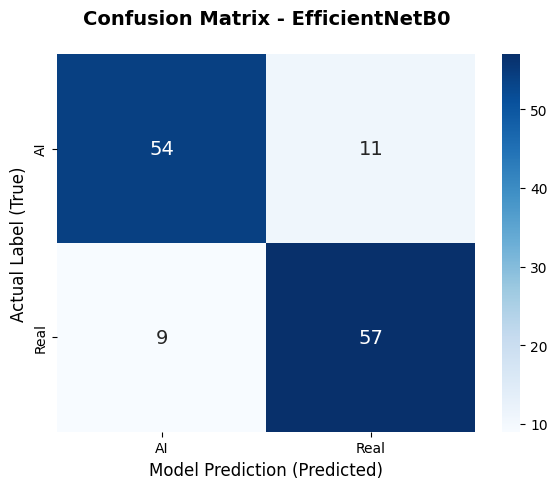

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={"size": 14})
plt.title('Confusion Matrix - EfficientNetB0\n', fontsize=14, fontweight='bold')
plt.xlabel('Model Prediction (Predicted)', fontsize=12)
plt.ylabel('Actual Label (True)', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_efficientnetb0_scen1.png', dpi=300)
plt.show()

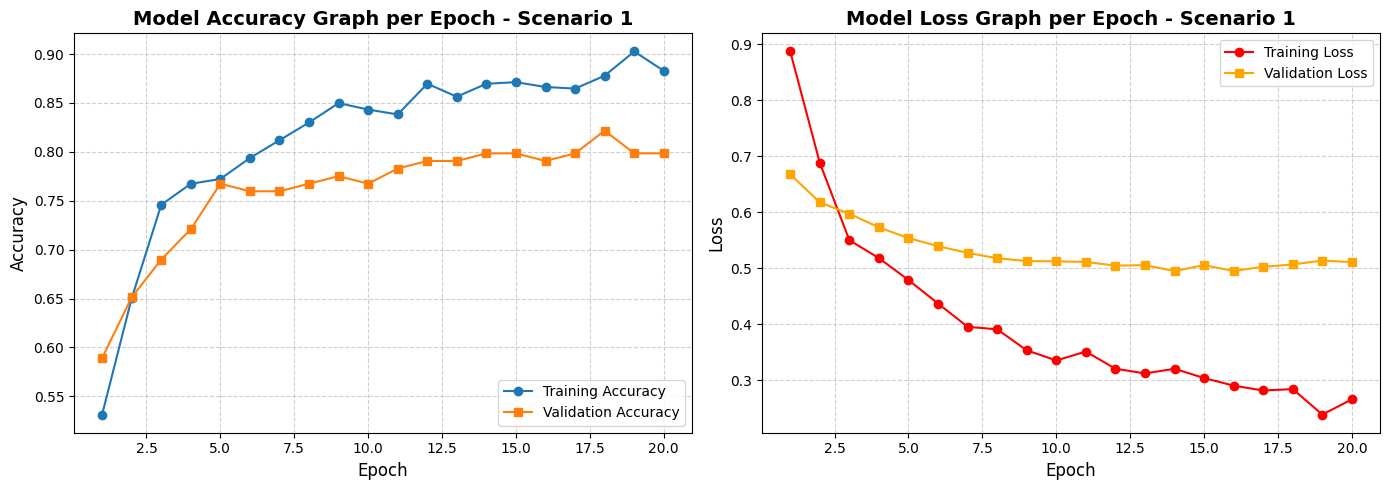

In [ ]:
training_acc = history_scen1.history['accuracy']
val_acc = history_scen1.history['val_accuracy']
training_loss = history_scen1.history['loss']
val_loss = history_scen1.history['val_loss']
epochs_range = range(1, len(training_acc) + 1)

plt.figure(figsize=(14, 5))

# Graph 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s')
plt.title('Model Accuracy Graph per Epoch - Scenario 1', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Graph 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss', marker='o', color='red')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='s', color='orange')
plt.title('Model Loss Graph per Epoch - Scenario 1', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('grafik_learning_curve_scen1.png', dpi=300)
plt.show()